In [0]:
import boto3
import pandas as pd

# Credenciales
ACCESS_KEY = ""
SECRET_KEY = ""
BUCKET     = "ptbxl-tfm-andrea"
REGION     = "eu-west-1"

# Crear cliente S3 con boto3
s3 = boto3.client(
    's3',
    aws_access_key_id     = ACCESS_KEY,
    aws_secret_access_key = SECRET_KEY,
    region_name           = REGION
)

# Verificar conexión
try:
    response = s3.list_objects_v2(Bucket=BUCKET, Prefix="bronze/", Delimiter="/")
    print("Conexión con S3 exitosa. Carpetas encontradas:")
    for obj in response.get('CommonPrefixes', []):
        print(f"   {obj['Prefix']}")
except Exception as e:
    print(f"Error: {e}")

✅ Conexión con S3 exitosa. Carpetas encontradas:
   bronze/FileYear=2026/


In [0]:
# Leer el CSV de metadatos de PTB-XL desde S3
import pandas as pd
import io

# Descargar el CSV desde S3
obj = s3.get_object(Bucket=BUCKET, Key="bronze/FileYear=2026/FileMonth=04/FileDay=13/ptbxl_database.csv")
df = pd.read_csv(io.BytesIO(obj['Body'].read()))

print(f"Dataset cargado correctamente")
print(f"   Registros: {len(df):,}")
print(f"   Columnas: {df.columns.tolist()}")
print()
df.head()

✅ Dataset cargado correctamente
   Registros: 21,799
   Columnas: ['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']



,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


**Exploración inicial del dataset**

In [0]:
print(df.describe())

             ecg_id    patient_id  ...  validated_by    strat_fold
count  21799.000000  21799.000000  ...  12421.000000  21799.000000
mean   10926.658379  11250.156521  ...      0.746075      5.503005
std     6302.393366   6235.026404  ...      1.178003      2.874948
min        1.000000    302.000000  ...      0.000000      1.000000
25%     5469.500000   5974.500000  ...      0.000000      3.000000
50%    10926.000000  11419.000000  ...      1.000000      6.000000
75%    16386.500000  16607.500000  ...      1.000000      8.000000
max    21837.000000  21797.000000  ...     11.000000     10.000000

[8 rows x 10 columns]


**Distribución por sexo**

In [0]:
display(df.groupby('sex').size().reset_index(name='cantidad'))

sex,cantidad
0,11354
1,10445


**Distribución por edad**

In [0]:
display(df[['age']].dropna())

age
56.0
19.0
37.0
24.0
19.0
18.0
54.0
48.0
55.0
22.0


**Distribución de diagnósticos SCP**

In [0]:
import ast

# Expandir los scp_codes (vienen como diccionario en string)
df['scp_codes_parsed'] = df['scp_codes'].apply(ast.literal_eval)

# Extraer solo el diagnóstico principal (el de mayor probabilidad)
def diagnostico_principal(d):
    if not d:
        return 'UNKNOWN'
    return max(d, key=d.get)

df['diagnostico_principal'] = df['scp_codes_parsed'].apply(diagnostico_principal)
display(df.groupby('diagnostico_principal').size().reset_index(name='cantidad').sort_values('cantidad', ascending=False))

diagnostico_principal,cantidad
NORM,9134
IMI,1677
NDT,1613
ASMI,1457
LVH,1141
LAFB,888
IRBBB,831
CLBBB,527
NST_,502
CRBBB,385


**Distribución por calidad de señal**

In [0]:
display(df.groupby('baseline_drift').size().reset_index(name='cantidad'))

baseline_drift,cantidad
", 1",1
", 2",1
", AVF",3
", AVL",3
", AVL,AVR",1
", AVL,V2",1
", AVL,V2,V5,V6",1
", AVL,V5",1
", AVL-V4",1
", AVR",4


**Registros normales vs patológicos**

In [0]:
# NORM = registro normal según SCP
df['es_normal'] = df['diagnostico_principal'] == 'NORM'
display(df.groupby('es_normal').size().reset_index(name='cantidad'))

es_normal,cantidad
false,12665
true,9134


**Leer una señal ECG real desde S3**

In [0]:
%pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.5.0
    Not uninstalling fsspec at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-0018dcd8-a453-4425-9e62-a262e55e683b
    Can't uninstall 'fsspec'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


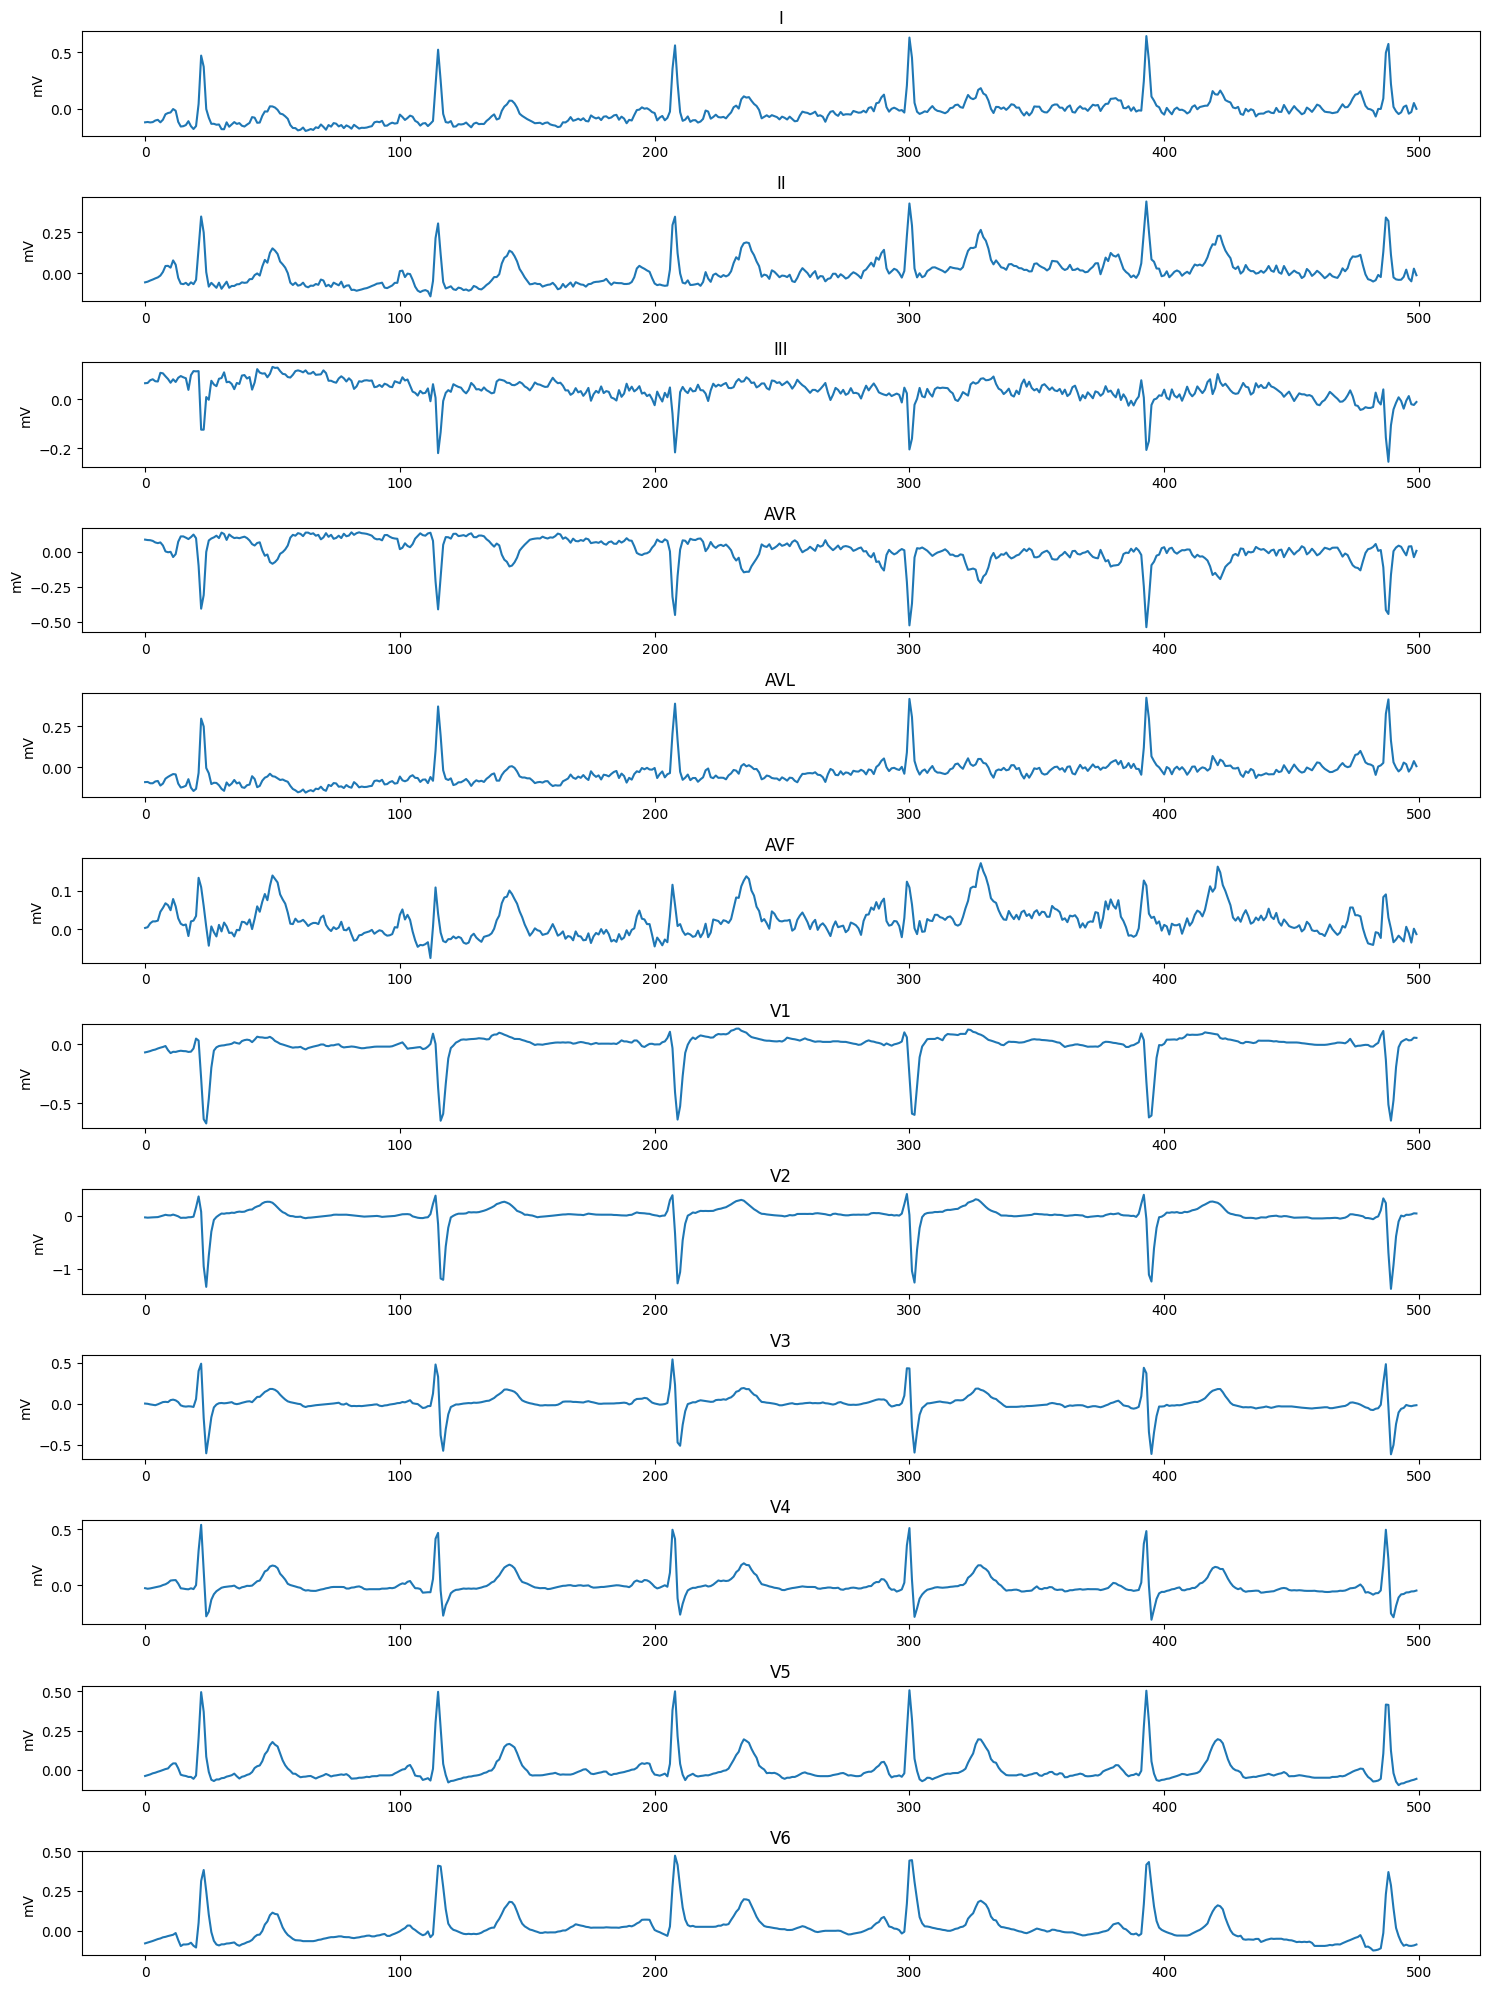

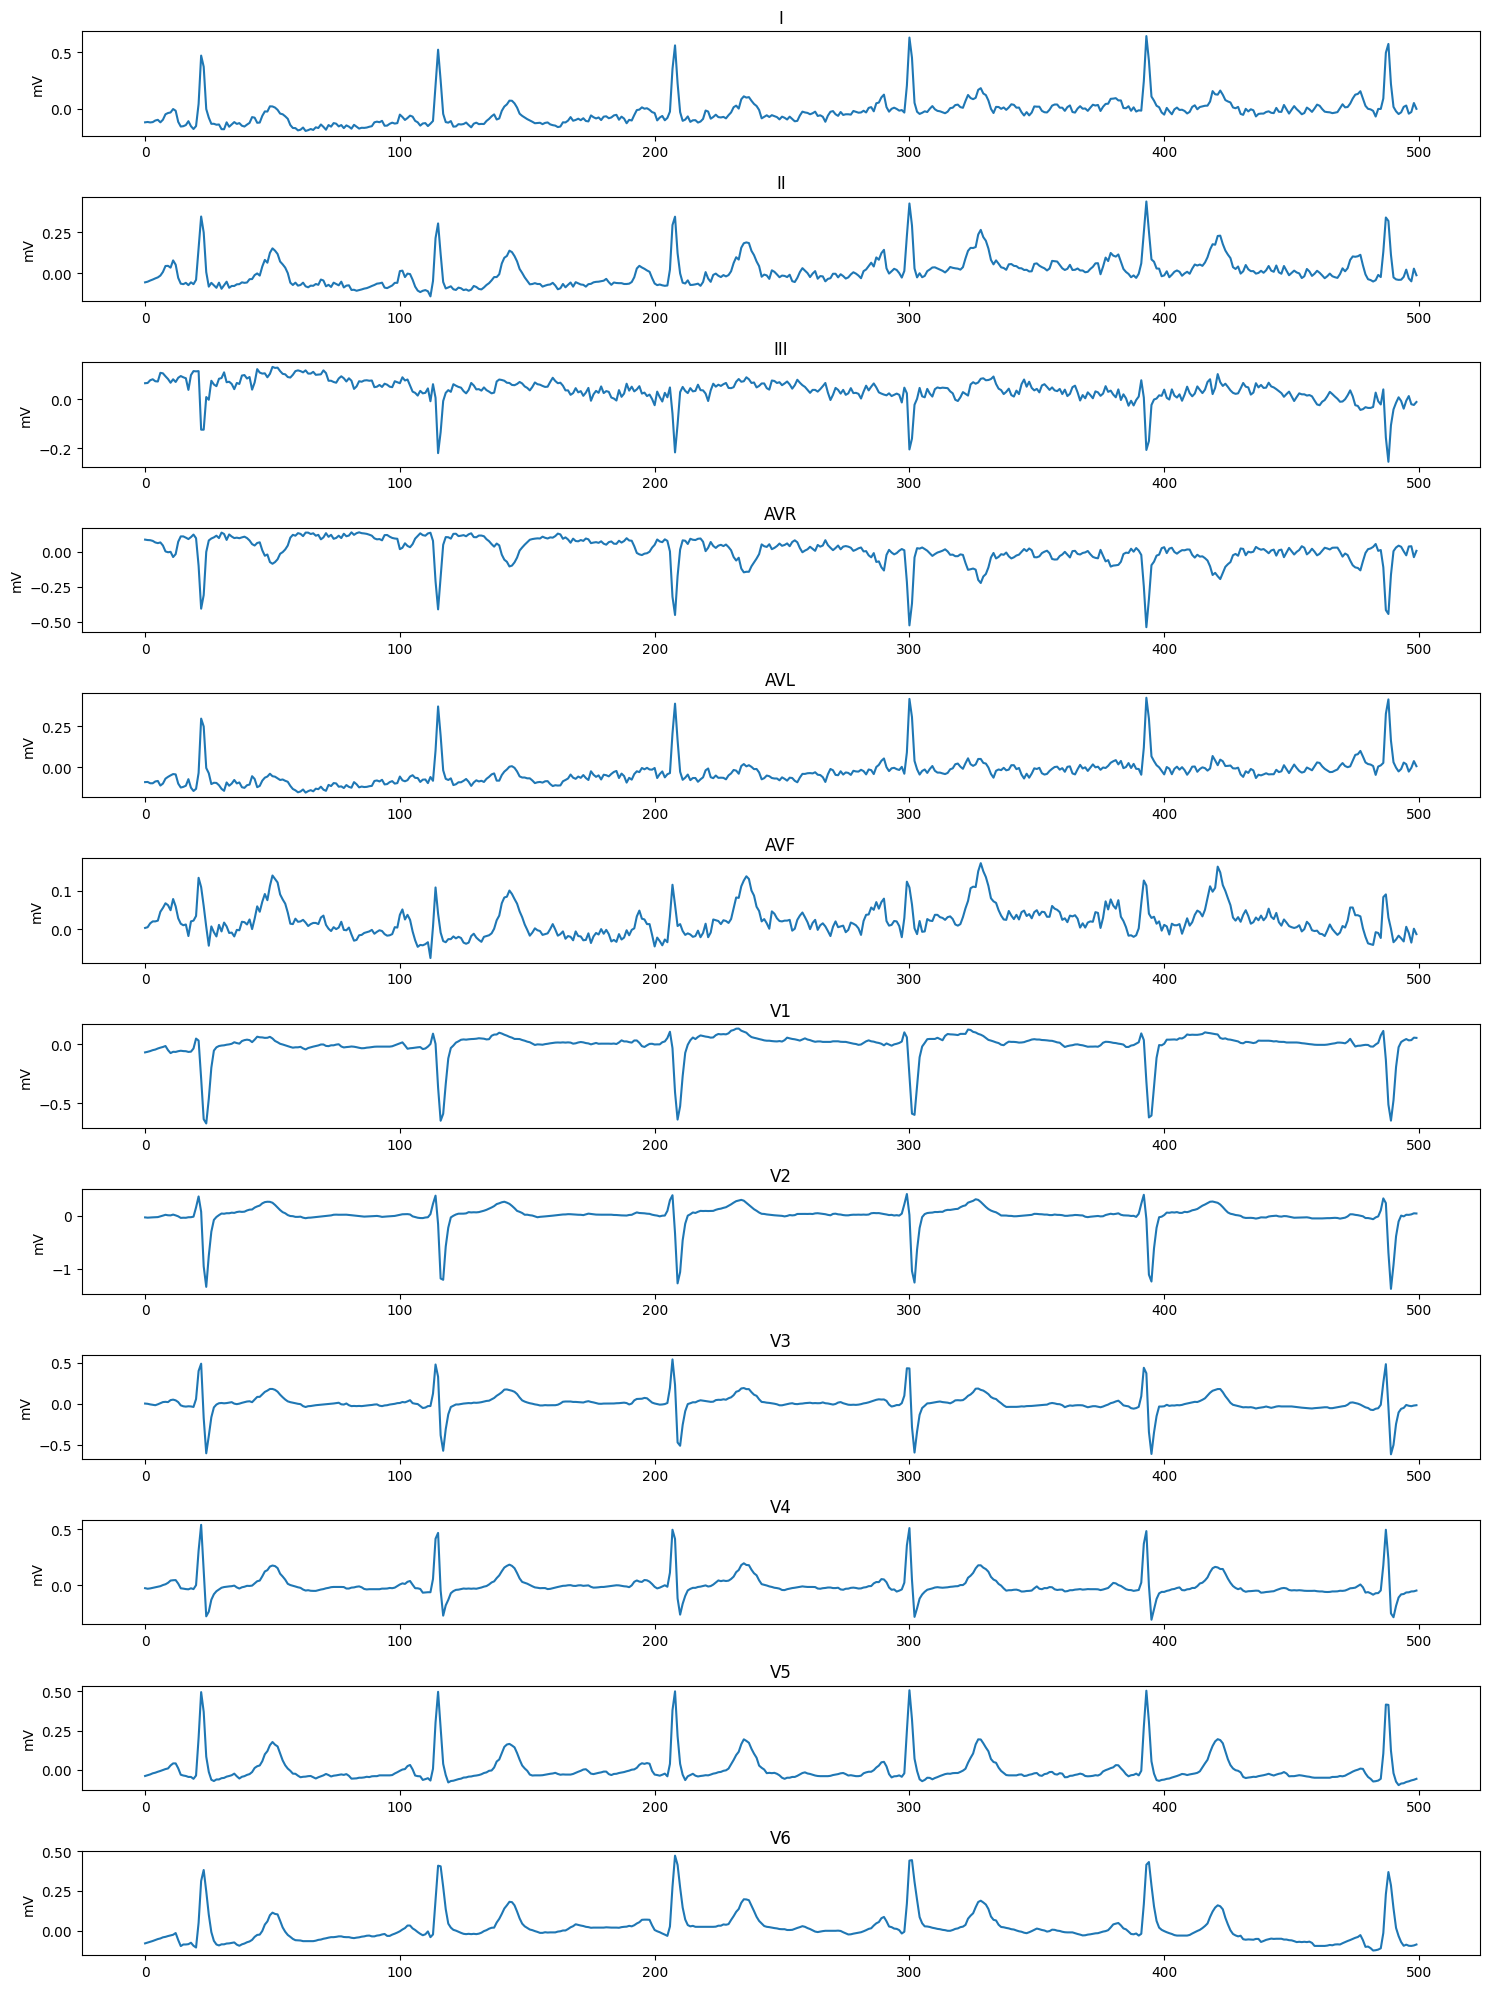

In [0]:
import wfdb
import tempfile
import os
import matplotlib.pyplot as plt

# Descargar los archivos de un registro de ejemplo (primer registro)
ecg_id = df.iloc[0]['filename_lr']  # ej: records100/00000/00001_lr

for ext in ['.dat', '.hea']:
    key = f"bronze/FileYear=2026/FileMonth=04/FileDay=13/{ecg_id}{ext}"
    local_path = f"/tmp/{ecg_id.split('/')[-1]}{ext}"
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    s3.download_file(BUCKET, key, local_path)

# Leer la señal con wfdb
record = wfdb.rdrecord(f"/tmp/{ecg_id.split('/')[-1]}")
fig, axes = plt.subplots(12, 1, figsize=(15, 20))
for i, ax in enumerate(axes):
    ax.plot(record.p_signal[:500, i])
    ax.set_title(record.sig_name[i])
    ax.set_ylabel('mV')
plt.tight_layout()
display(fig)

**Comparar señal normal vs anómala**

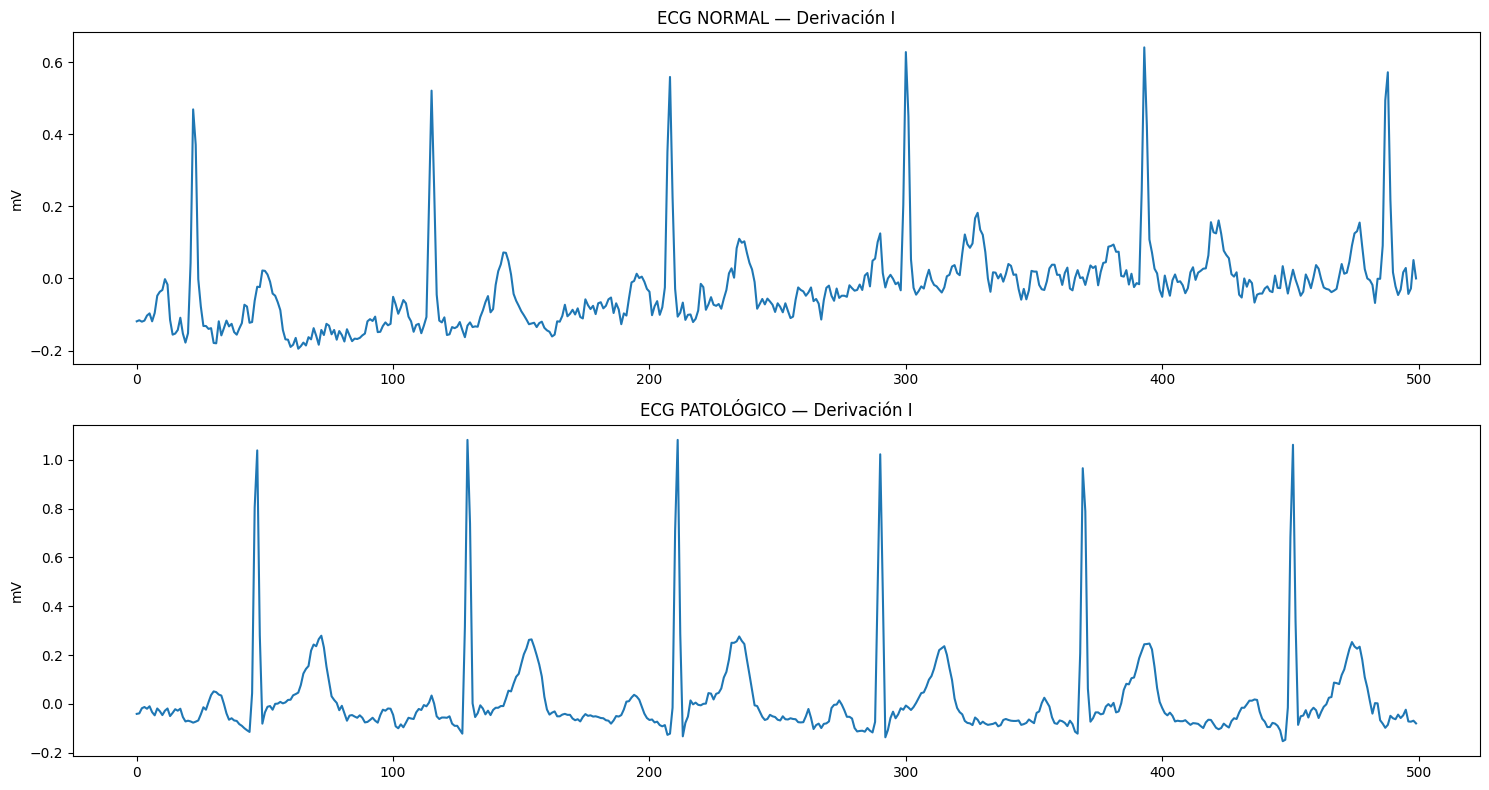

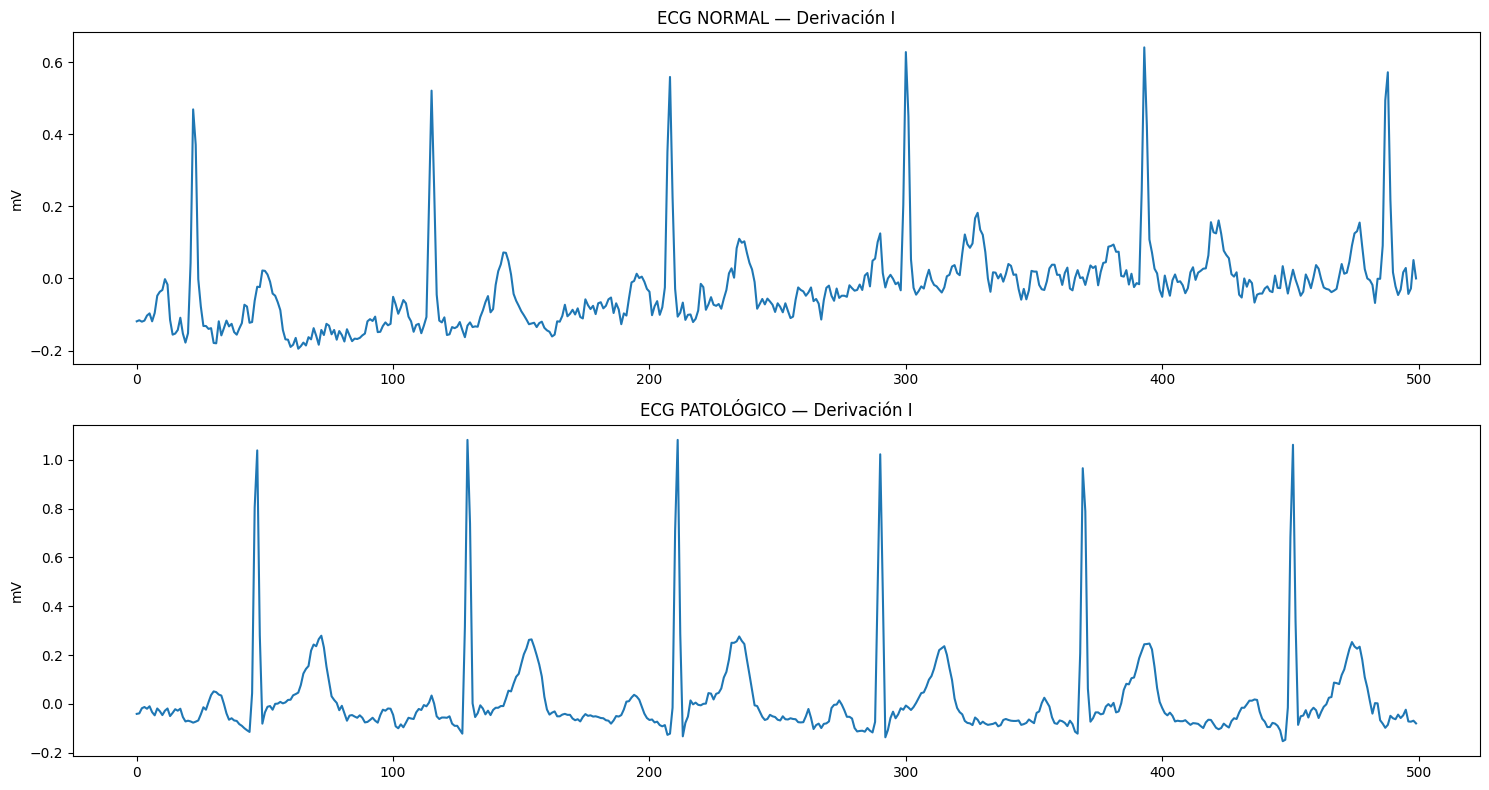

In [0]:
# Obtener un registro normal y uno patológico
normal_id = df[df['es_normal'] == True].iloc[0]['filename_lr']
anomalo_id = df[df['es_normal'] == False].iloc[0]['filename_lr']

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

for idx, (ecg_id, label) in enumerate([(normal_id, 'NORMAL'), (anomalo_id, 'PATOLÓGICO')]):
    for ext in ['.dat', '.hea']:
        key = f"bronze/FileYear=2026/FileMonth=04/FileDay=13/{ecg_id}{ext}"
        local_path = f"/tmp/{ecg_id.split('/')[-1]}{ext}"
        s3.download_file(BUCKET, key, local_path)
    
    record = wfdb.rdrecord(f"/tmp/{ecg_id.split('/')[-1]}")
    # Mostrar solo derivación I
    axes[idx].plot(record.p_signal[:500, 0])
    axes[idx].set_title(f'ECG {label} — Derivación I')
    axes[idx].set_ylabel('mV')

plt.tight_layout()
display(fig)